<a href="https://colab.research.google.com/github/Ishalllll/Drought-Severity-Classification-in-Indonesia/blob/main/Notebook/Drought_Severity_Classification_in_Indonesia_based_on_Meteorological_Features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Drought Severity Classification in Indonesia based on Meteorological Features


| Fitur                          | Nama Lengkap                       | Satuan      | Deskripsi                                                                                                                                                                    |
| ------------------------------ | ---------------------------------- | ----------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `kecamatan_id`                 | ID Kecamatan                       | Kode        | Identitas unik kecamatan. Digunakan untuk identifikasi, bukan sebagai fitur model.                                                                                           |
| `kecamatan`                    | Nama Kecamatan                     | -           | Nama wilayah kecamatan.                                                                                                                                                      |
| `kabupaten`                    | Nama Kabupaten/Kota                | -           | Kabupaten atau kota tempat kecamatan berada.                                                                                                                                 |
| `provinsi`                     | Nama Provinsi                      | -           | Provinsi tempat kecamatan berada.                                                                                                                                            |
| `year`                         | Tahun                              | Tahun       | Tahun pengamatan data iklim.                                                                                                                                                 |
| `month`                        | Bulan                              | 1–12        | Bulan pengamatan, berguna untuk menangkap pola musim hujan dan kemarau.                                                                                                      |
| `date`                         | Tanggal                            | Tanggal     | Gabungan tahun dan bulan pengamatan.                                                                                                                                         |
| `precipitation`                | Precipitation (PR)                 | mm          | Total curah hujan selama periode pengamatan. Semakin rendah nilainya, semakin tinggi potensi kekeringan.                                                                     |
| `potential_evapotranspiration` | Potential Evapotranspiration (PET) | mm          | Jumlah air yang berpotensi menguap jika air tersedia tanpa batas. Menggambarkan kebutuhan atmosfer terhadap air.                                                             |
| `actual_evapotranspiration`    | Actual Evapotranspiration (AET)    | mm          | Jumlah air yang benar-benar menguap dan ditranspirasikan tanaman. Biasanya menurun saat terjadi kekeringan.                                                                  |
| `soil_moisture`                | Soil Moisture                      | mm          | Kandungan air dalam tanah. Salah satu indikator paling langsung kondisi kekeringan.                                                                                          |
| `runoff`                       | Runoff (RO)                        | mm          | Limpasan air permukaan akibat hujan. Biasanya berkurang saat kondisi kering.                                                                                                 |
| `max_temperature`              | Maximum Temperature (TMMX)         | °C × 10*    | Suhu maksimum rata-rata. Suhu tinggi mempercepat penguapan dan meningkatkan risiko kekeringan.                                                                               |
| `min_temperature`              | Minimum Temperature (TMMN)         | °C × 10*    | Suhu minimum rata-rata. Membantu menggambarkan kondisi iklim lokal.                                                                                                          |
| `vapor_pressure`               | Vapor Pressure (VAP)               | kPa × 1000* | Tekanan uap air aktual di atmosfer. Menggambarkan kelembapan udara.                                                                                                          |
| `vapor_pressure_deficit`       | Vapor Pressure Deficit (VPD)       | kPa × 1000* | Selisih antara kapasitas maksimum udara menahan uap air dan kondisi aktualnya. Semakin tinggi nilainya, semakin besar potensi kehilangan air dari tanah dan tanaman.         |
| `pdsi`                         | Palmer Drought Severity Index      | Indeks      | Indeks kekeringan yang menggabungkan curah hujan, evapotranspirasi, dan neraca air tanah. Nilai negatif menunjukkan kondisi kering, nilai positif menunjukkan kondisi basah. |



---

## 1. Setup and Load Dataset

In [1]:
from google.colab import files

import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import chi2_contingency
import math
import seaborn as sns
import matplotlib.pyplot as plt
import datetime

from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

In [2]:
# Upload CSV
uploaded = files.upload()

filename = list(uploaded.keys())[0]

Saving dataset_6000_rows_cols_dropped.csv to dataset_6000_rows_cols_dropped.csv


## Formatting

In [3]:
df_raw = pd.read_csv(filename)
# Formatting label ke dalam tiga kelas klasifikasi
def reclassify(pdsi):
    if pdsi >= -2:   return "mild"
    else:            return "severe"

df_raw["new_label"] = df_raw["pdsi"].apply(reclassify)

In [4]:
# Buat keperluan laporan ajaa
grouped_data = df_raw.groupby('new_label')['pdsi']
pdsi_min = grouped_data.min()
pdsi_max = grouped_data.max()

for label in df_raw['new_label'].unique().tolist():
  print(f"{label} min value: {pdsi_min[label]:.2f}")
  print(f"{label} max value: {pdsi_max[label]:.2f}")
  print(f"===========\n")

mild min value: -0.94
mild max value: 901.80

severe min value: -598.00
severe max value: -1.17



In [5]:
# =====================================================
# RENAME KOLOM
# =====================================================

df_raw = df_raw.rename(columns={
    'KDCPUM': 'kecamatan_id',
    'WADMKC': 'kecamatan',
    'WADMKK': 'kabupaten',
    'WADMPR': 'provinsi',

    'pr': 'precipitation',
    'pet': 'potential_evapotranspiration',
    'aet': 'actual_evapotranspiration',
    'soil': 'soil_moisture',
    'ro': 'runoff',

    'tmmx': 'max_temperature',
    'tmmn': 'min_temperature',

    'vap': 'vapor_pressure',
    'vpd': 'vapor_pressure_deficit'
})

# =====================================================
# BUAT KOLOM DATE
# =====================================================

df_raw['date'] = pd.to_datetime(
    dict(
        year=df_raw['year'],
        month=df_raw['month'],
        day=1
    )
)

# =====================================================
# HAPUS KOLOM TIDAK DIPERLUKAN
# =====================================================

drop_cols = [
    'KDPKAB',
    'pdsi',
    'drought_class'
]

df_raw = df_raw.drop(
    columns=[c for c in drop_cols if c in df_raw.columns]
)

# Exploratory Data Analysis

Records	: 6000
Columns	: 17
Date Range	: 2023-01-01 to 2024-12-01
Duplicated	: 0
Dataframe Values: 


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 6000.
  res = hypotest_fun_out(*samples, **kwds)


,Columns,Data Types,Unique,Missing Values,Missing Values(%),Distributions,Outliers,Unique Values
0,kecamatan_id,object,239,216,3.60,-,-,"[nan, 11.01.01, 11.01.02, 11.01.03, 11.01.04, ..."
2,kabupaten,object,23,48,0.80,-,-,"[nan, Kepulauan Tanimbar, Bengkulu Utara, Memp..."
3,provinsi,object,8,24,0.40,-,-,"[Maluku, Bengkulu, Kalimantan Barat, Papua Ten..."
15,new_label,object,2,0,0.00,-,-,"[mild, severe]"
1,kecamatan,object,238,192,3.20,-,-,"[nan, Wuyuneri, Bakongan, Kluet Utara, Kluet S..."
5,month,int64,12,0,0.00,Non-normal,0,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
14,year,int64,2,0,0.00,Non-normal,0,"[2023, 2024]"
11,max_temperature,float64,5762,0,0.00,Non-normal,306,"[317.28, 313.0, 302.0, 300.8888888888889, 212...."
13,vapor_pressure_deficit,float64,5902,0,0.00,Non-normal,144,"[97.44, 88.0, 70.73529411764706, 60.4444444444..."
12,vapor_pressure,float64,5990,0,0.00,Non-normal,273,"[3026.1199999999994, 3007.0, 2922.617647058823..."



Descriptive Statistics (Numeric Data Types):


,actual_evapotranspiration,month,potential_evapotranspiration,precipitation,runoff,soil_moisture,min_temperature,max_temperature,vapor_pressure,vapor_pressure_deficit,year,date
count,6000.000000,6000.00000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000
mean,981.291179,6.50000,1059.842029,217.790249,119.655143,1244.560040,224.765628,302.600471,2849.644211,74.750484,2023.500000,2023-12-16 09:59:59.999999744
min,100.000000,1.00000,515.011526,6.000000,0.000000,53.000000,74.747975,168.969782,1472.454545,2.689822,2023.000000,2023-01-01 00:00:00
25%,871.954672,3.75000,901.286091,110.701369,6.996951,754.235201,213.161167,290.734215,2682.468197,62.051541,2023.000000,2023-06-23 12:00:00
50%,983.742840,6.50000,1068.296327,205.759367,92.050248,1215.172492,238.493535,312.022739,2989.338934,76.314144,2023.500000,2023-12-16 12:00:00
75%,1093.949573,9.25000,1211.804581,301.033527,199.866942,1706.139980,248.050583,322.577049,3107.581362,90.762102,2024.000000,2024-06-08 12:00:00
max,1466.000000,12.00000,1612.000000,1110.000000,1033.000000,2737.000000,276.649123,345.908733,3466.769231,153.515789,2024.000000,2024-12-01 00:00:00
std,157.697852,3.45234,187.807819,125.553258,119.992138,564.151870,35.108997,29.146817,367.193802,24.429060,0.500042,NaN



Descriptive Statistics (Object Data Types):


,kecamatan_id,kecamatan,kabupaten,provinsi,new_label
count,5784,5808,5952,5976,6000
unique,239,238,23,8,2
top,11.05.02,Sawang,Aceh Utara,Aceh,mild
freq,48,48,648,5784,4356



Target Class Distribution:
new_label
mild      4356
severe    1644
Name: count, dtype: int64

Percentage:
new_label
mild      72.6
severe    27.4
Name: proportion, dtype: float64

Distributions Visualization (Numeric Data Types):


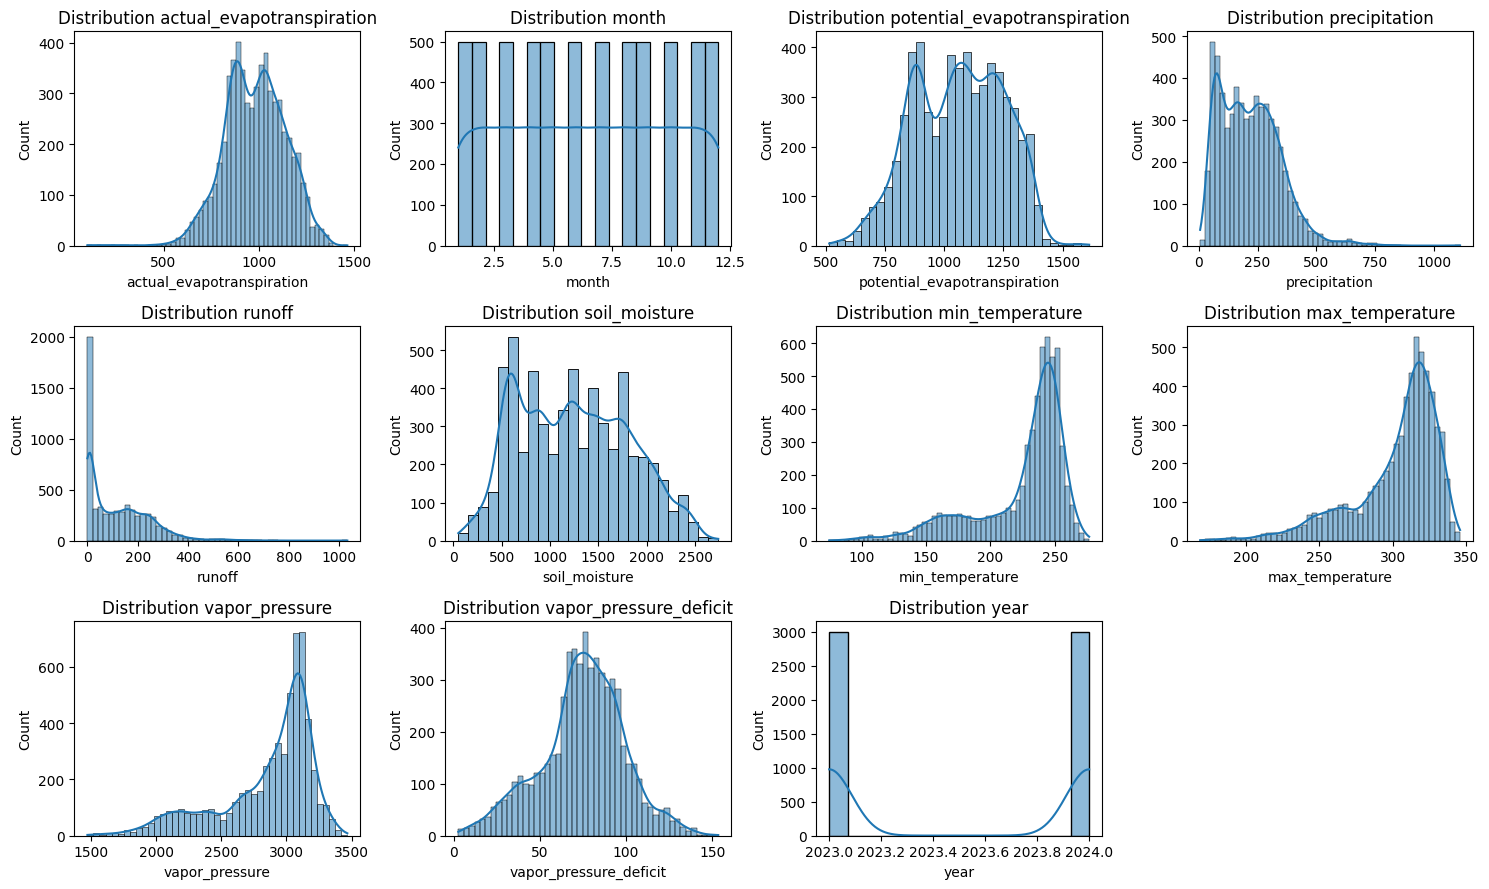


Heatmap:


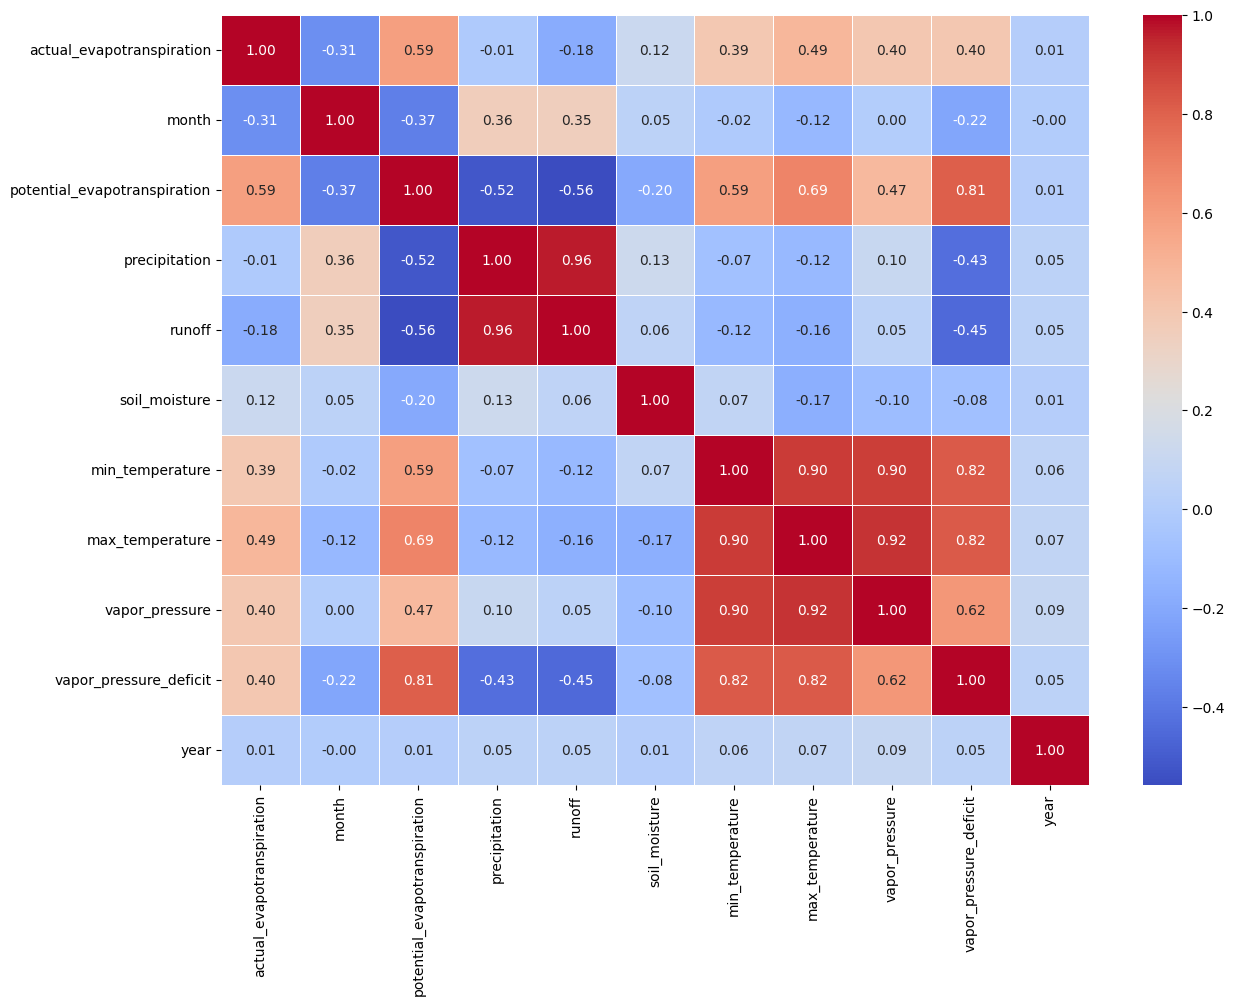

In [6]:
def data_understanding(df, kolom_target):
  prepare = []
  for column in df.columns:
    # Identifikasi missing values
    percent_missing = (df[column].isnull().sum()/len(df[column]))*100

    # Identifikasi bentuk distribusi
    if pd.api.types.is_numeric_dtype(df[column]):
      stat_,p_value = stats.shapiro(df[column].dropna())
      distrib = "Normal" if p_value > 0.05 else "Non-normal"
    else:
      distrib = '-'

    # Identifikasi outliers
    if pd.api.types.is_numeric_dtype(df[column]):
      q1 = np.quantile(df[column].dropna(),0.25)
      q3 = np.quantile(df[column].dropna(),0.75)
      iqr = q3 - q1

      delta = 1.5 * iqr
      lower_bound = q1 - delta
      upper_bound = q3 + delta
      outliers = (df[column] < lower_bound) | (df[column] > upper_bound)
      outliers_sum = df[column][outliers].count()
    else:
      outliers_sum = '-'

    prepare.append(
        [
            column,
            df[column].dtype,
            df[column].nunique(),
            df[column].isnull().sum(),
            f"{percent_missing:.2f}",
            distrib,
            outliers_sum,
            df[column].unique()
        ]
    )
  print(f"Records\t: {df.shape[0]}")
  print(f"Columns\t: {df.shape[1]}")
  print(
    f"Date Range\t: "
    f"{df['date'].min().date()} "
    f"to "
    f"{df['date'].max().date()}"
  )
  print(f"Duplicated\t: {df.duplicated().sum()}")
  print('Dataframe Values: ')
  dfv = pd.DataFrame(prepare,columns = ['Columns','Data Types','Unique','Missing Values','Missing Values(%)','Distributions','Outliers','Unique Values'])
  dfv['Data Types'] = dfv['Data Types'].astype(str)
  display(dfv.sort_values("Data Types", ascending = False))

  print(f"="*180,"\n")
  print('Descriptive Statistics (Numeric Data Types):')
  display(df.describe())
  print(f"="*180,"\n")
  print('Descriptive Statistics (Object Data Types):')
  display(df.describe(include='O'))
  print(f"="*180,"\n")

  # Target label distributions
  print("Target Class Distribution:")
  print(f'{df[f'{kolom_target}'].value_counts()}\n')

  print("Percentage:")
  print(f'{df[f'{kolom_target}'].value_counts(normalize=True).round(3)*100}')
  print(f"="*180,"\n")

  print('Distributions Visualization (Numeric Data Types):')
  numeric_cols = df.select_dtypes(include='number').columns

  cols_per_row = 4
  n_cols = len(numeric_cols)
  n_rows = math.ceil(n_cols / cols_per_row)

  fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(15, 3 * n_rows))
  axes = axes.flatten()

  for i, col in enumerate(numeric_cols):
      sns.histplot(df[col].dropna(), kde=True, ax=axes[i])
      axes[i].set_title(f'Distribution {col}')

  for j in range(i + 1, len(axes)):
      axes[j].set_visible(False)

  plt.tight_layout()
  plt.show()

  print(f"="*180,"\n")
  print('Heatmap:')
  plt.figure(figsize=(14, 10))
  sns.heatmap(df.select_dtypes(include='number').corr(),fmt='.2f',annot=True,cmap='coolwarm',linewidths=0.5)

data_understanding(df_raw,'new_label')

# Preprocessing

In [7]:
# Mengembalikan format scale normal dari GEE
scale_factors = {
    'pdsi': 0.01,
    'aet': 0.1, 'pet': 0.1, 'soil': 0.1,
    'tmmn': 0.1, 'tmmx': 0.1,
    'vap': 0.001, 'vpd': 0.01,
    # pr dan ro tidak perlu di-scale
}
for col, factor in scale_factors.items():
    if col in df_raw.columns:
        df_raw[col] = df_raw[col] * factor

## Feature Engineering

### Feature Creation

In [8]:
df = df_raw.copy()

In [9]:
eps = 1e-6

In [10]:
# Water Balance
df["water_balance"] = df["precipitation"] - df["potential_evapotranspiration"]  # SPEI basis (Vicente-Serrano 2010)
df["aridity_index"] = df["precipitation"] / (df["potential_evapotranspiration"] + eps) # UNEP 1992 (P/PET)
df["evaporative_stress"]   = df["actual_evapotranspiration"] / (df["potential_evapotranspiration"] + eps) # ESI/ESR (Anderson 2007/2011)
df["climatic_water_deficit"] = df["potential_evapotranspiration"] - df["actual_evapotranspiration"] # Climatic Water Deficit

In [11]:
# Logis / Fisis
df["diurnal_temperature_range"] = df["max_temperature"] - df["min_temperature"]                                       # diurnal temp range
df["relative_humidity_proxy"] = df["vapor_pressure"] / (df["vapor_pressure"] + df["vapor_pressure_deficit"] + eps)    # proksi kelembapan relatif
df["runoff_ratio"] = df["runoff"]  / (df["precipitation"] + eps)                                                      # fraksi hujan jadi limpasan

In [12]:
# Cyclical Encoding
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

# Fase Bulan: Barat (basah) Nov-Mar, Timur (kering) Mei-Sep, sisanya transisi
def monsoon(m):
    if m in [11, 12, 1, 2, 3]:  return "west_wet"
    if m in [5, 6, 7, 8, 9]:    return "east_dry"
    return "transition"
df["monsoon_phase"] = df["month"].map(monsoon)

###Feature Selection

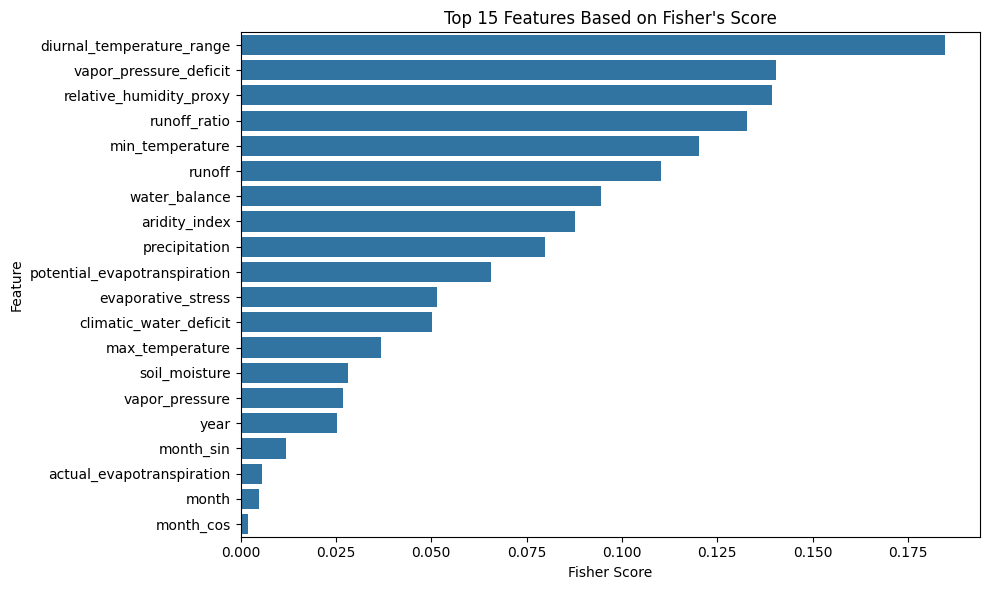

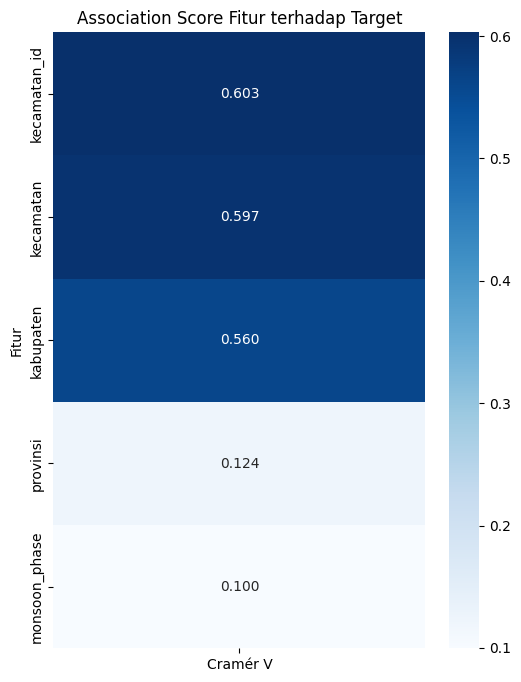

In [13]:
def feature_selection(df,target):
  # Separate features from target
  X = df.drop(columns=[target])
  y = df[target]

  # Separate numerical and categorical features from X
  numerical_cols = X.select_dtypes(include='number')
  categorical_cols = X.select_dtypes(include='O')

  def fisher_score(X_num, y):
      scores = {}

      for col in X_num.columns:
          x = X_num[col]
          x = pd.to_numeric(x, errors='coerce')

          overall_mean = x.mean()

          numerator = 0
          denominator = 0

          for cls in y.unique():
              x_class = x[y == cls]
              n_class = len(x_class)

              if n_class == 0:
                  continue

              mean_class = x_class.mean()
              var_class = x_class.var(ddof=0)

              numerator += n_class * (mean_class - overall_mean) ** 2
              denominator += n_class * var_class

          if denominator == 0 or pd.isna(denominator):
              scores[col] = 0
          else:
              scores[col] = numerator/denominator

      return pd.Series(scores).sort_values(ascending=False)


  scores = fisher_score(numerical_cols, y)

  top_scores = scores.head(15)

  plt.figure(figsize=(10, 6))
  sns.barplot(
      x=scores.values,
      y=scores.index
  )

  plt.title("Top 15 Features Based on Fisher's Score")
  plt.xlabel("Fisher Score")
  plt.ylabel("Feature")
  plt.tight_layout()
  plt.show()
  print(f"="*180,"\n")

  def cramers_v(col_fitur, col_target):
    # Langkah 1: buat tabel silang (frekuensi observasi)
    tabel = pd.crosstab(col_fitur, col_target)

    # Langkah 2: jalankan Chi-Square
    chi2, p_value, dof, expected = chi2_contingency(tabel)

    # Langkah 3: hitung Cramér's V dari hasil Chi-Square
    n = len(col_fitur)
    k = min(tabel.shape) - 1

    # Handle cases where k is 0 (i.e., one of the variables has only one unique value)
    if k == 0 or n == 0: # Also check for n=0 although unlikely here
        return 0, 1, 0 # Return 0 for chi2, 1 for p-value (no association), and 0 for Cramér's V

    v = np.sqrt(chi2 / (n * k))

    return chi2, p_value, v

  # Fitur kategorikal yang diuji

  results = []
  for col in categorical_cols:
      chi2, p_value, v = cramers_v(df[col], df[target])
      results.append({
          'Fitur':col,
          'Chi-Square':round(chi2, 4),
          'p-value':round(p_value, 4),
          'Cramér V':round(v, 4)
      })

  df_results = pd.DataFrame(results).sort_values('Cramér V', ascending=False)

  heatmap_data = df_results.set_index("Fitur")[["Cramér V"]]

  plt.figure(figsize=(6, 8))
  sns.heatmap(
      heatmap_data,
      annot=True,
      fmt=".3f",
      cmap="Blues"
  )

  plt.title("Association Score Fitur terhadap Target")
  plt.show()

feature_selection(df,'new_label')

Records	: 6000
Columns	: 20
Date Range	: 2023-01-01 to 2024-12-01
Duplicated	: 0
Dataframe Values: 


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 6000.
  res = hypotest_fun_out(*samples, **kwds)


,Columns,Data Types,Unique,Missing Values,Missing Values(%),Distributions,Outliers,Unique Values
0,kecamatan_id,object,239,216,3.60,-,-,"[nan, 11.01.01, 11.01.02, 11.01.03, 11.01.04, ..."
1,kecamatan,object,238,192,3.20,-,-,"[nan, Wuyuneri, Bakongan, Kluet Utara, Kluet S..."
11,new_label,object,2,0,0.00,-,-,"[mild, severe]"
18,relative_humidity_proxy,float64,6000,0,0.00,Non-normal,214,"[0.968804824953321, 0.9715670433048249, 0.9763..."
17,diurnal_temperature_range,float64,5330,0,0.00,Non-normal,110,"[61.599999999999966, 63.0, 64.6764705882353, 6..."
16,climatic_water_deficit,float64,1880,0,0.00,Non-normal,1234,"[414.31999999999994, 1026.0, 0.0, 0.1662971175..."
15,evaporative_stress,float64,5994,0,0.00,Non-normal,1210,"[0.7120458141891761, 0.30440677945463945, 0.99..."
14,aridity_index,float64,6000,0,0.00,Non-normal,74,"[0.05181952124501715, 0.031864406758058024, 0...."
13,water_balance,float64,5997,0,0.00,Non-normal,1,"[-1364.28, -1428.0, -780.5, -764.6666666666667..."
10,vapor_pressure_deficit,float64,5902,0,0.00,Non-normal,144,"[97.44, 88.0, 70.73529411764706, 60.4444444444..."



Descriptive Statistics (Numeric Data Types):


,actual_evapotranspiration,potential_evapotranspiration,precipitation,runoff,soil_moisture,min_temperature,max_temperature,vapor_pressure,vapor_pressure_deficit,date,water_balance,aridity_index,evaporative_stress,climatic_water_deficit,diurnal_temperature_range,relative_humidity_proxy,runoff_ratio
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,981.291179,1059.842029,217.790249,119.655143,1244.560040,224.765628,302.600471,2849.644211,74.750484,2023-12-16 09:59:59.999999744,-842.051780,0.223954,0.938598,78.550850,77.834843,0.974815,0.405476
min,100.000000,515.011526,6.000000,0.000000,53.000000,74.747975,168.969782,1472.454545,2.689822,2023-01-01 00:00:00,-1604.000000,0.003868,0.062035,0.000000,26.980861,0.947522,0.000000
25%,871.954672,901.286091,110.701369,6.996951,754.235201,213.161167,290.734215,2682.468197,62.051541,2023-06-23 12:00:00,-1058.102273,0.098043,0.946416,0.000000,69.462140,0.970512,0.054762
50%,983.742840,1068.296327,205.759367,92.050248,1215.172492,238.493535,312.022739,2989.338934,76.314144,2023-12-16 12:00:00,-834.274905,0.198854,1.000000,0.000000,80.877368,0.974896,0.452627
75%,1093.949573,1211.804581,301.033527,199.866942,1706.139980,248.050583,322.577049,3107.581362,90.762102,2024-06-08 12:00:00,-623.509955,0.319341,1.000000,60.070770,88.584540,0.978983,0.676359
max,1466.000000,1612.000000,1110.000000,1033.000000,2737.000000,276.649123,345.908733,3466.769231,153.515789,2024-12-01 00:00:00,343.000000,1.447197,1.000000,1512.000000,116.090909,0.998570,0.930631
std,157.697852,187.807819,125.553258,119.992138,564.151870,35.108997,29.146817,367.193802,24.429060,NaN,274.909651,0.148506,0.120653,159.118486,15.248084,0.007182,0.286317



Descriptive Statistics (Object Data Types):


,kecamatan_id,kecamatan,new_label
count,5784,5808,6000
unique,239,238,2
top,11.05.02,Sawang,mild
freq,48,48,4356



Target Class Distribution:
new_label
mild      4356
severe    1644
Name: count, dtype: int64

Percentage:
new_label
mild      72.6
severe    27.4
Name: proportion, dtype: float64

Distributions Visualization (Numeric Data Types):


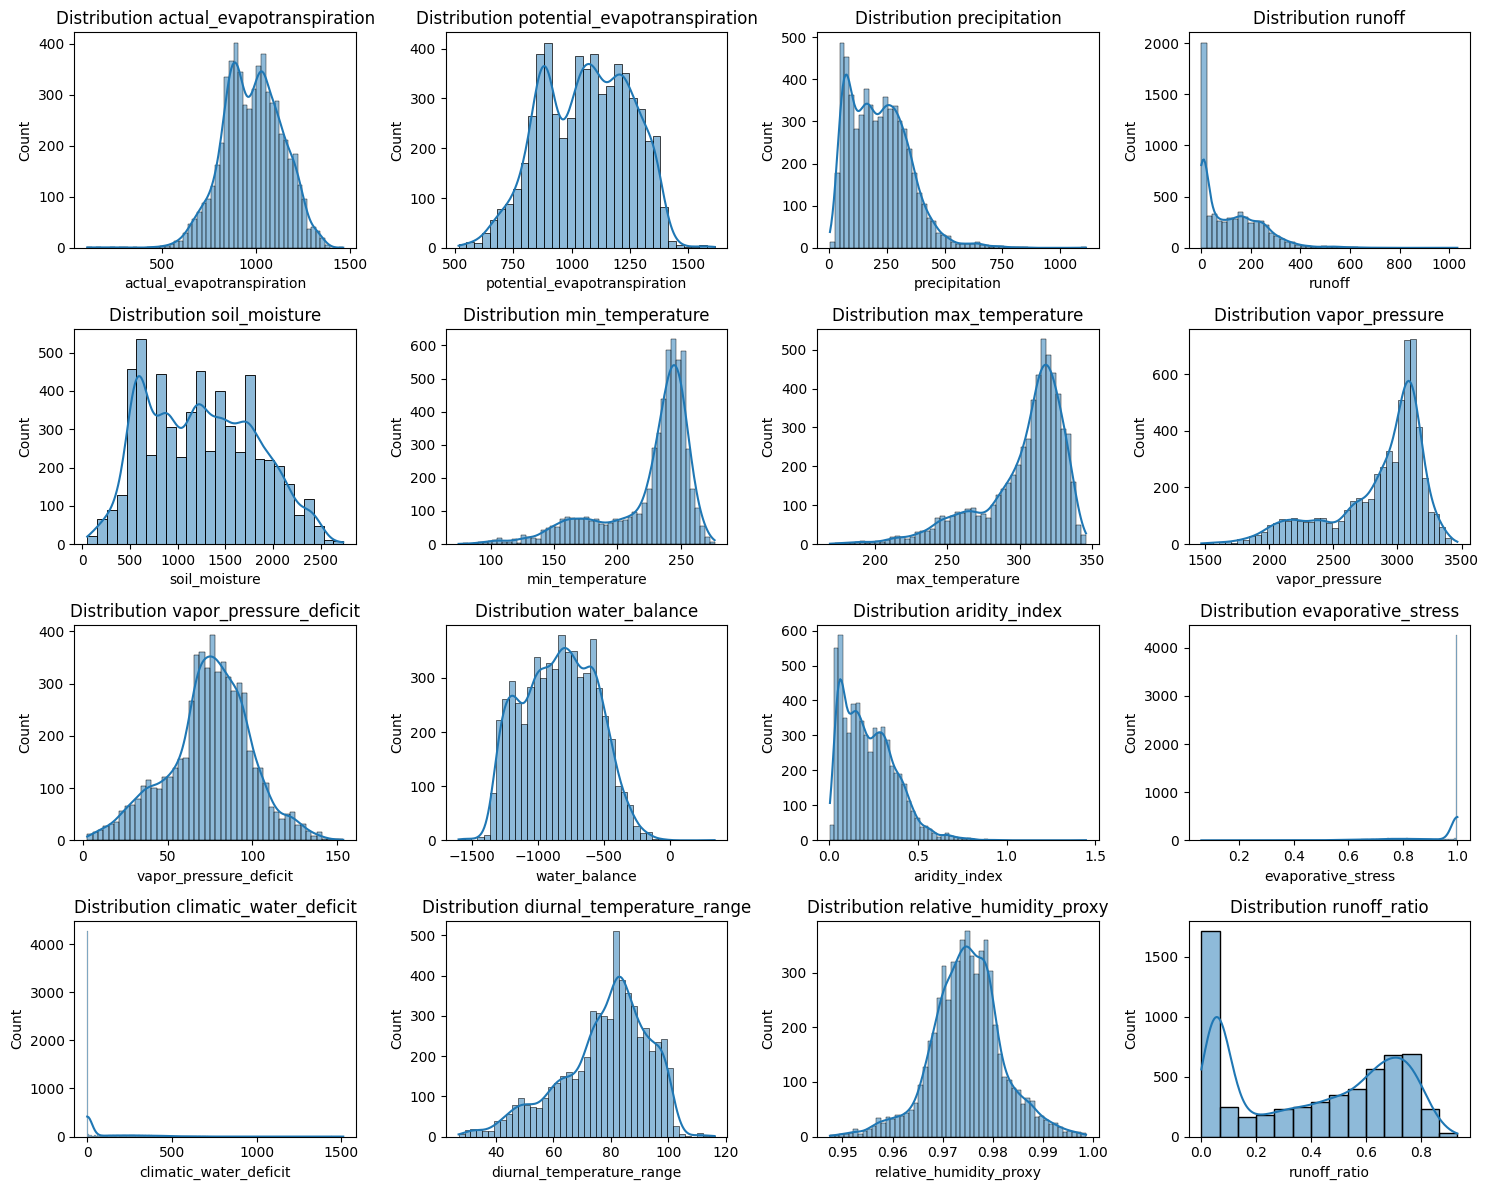


Heatmap:


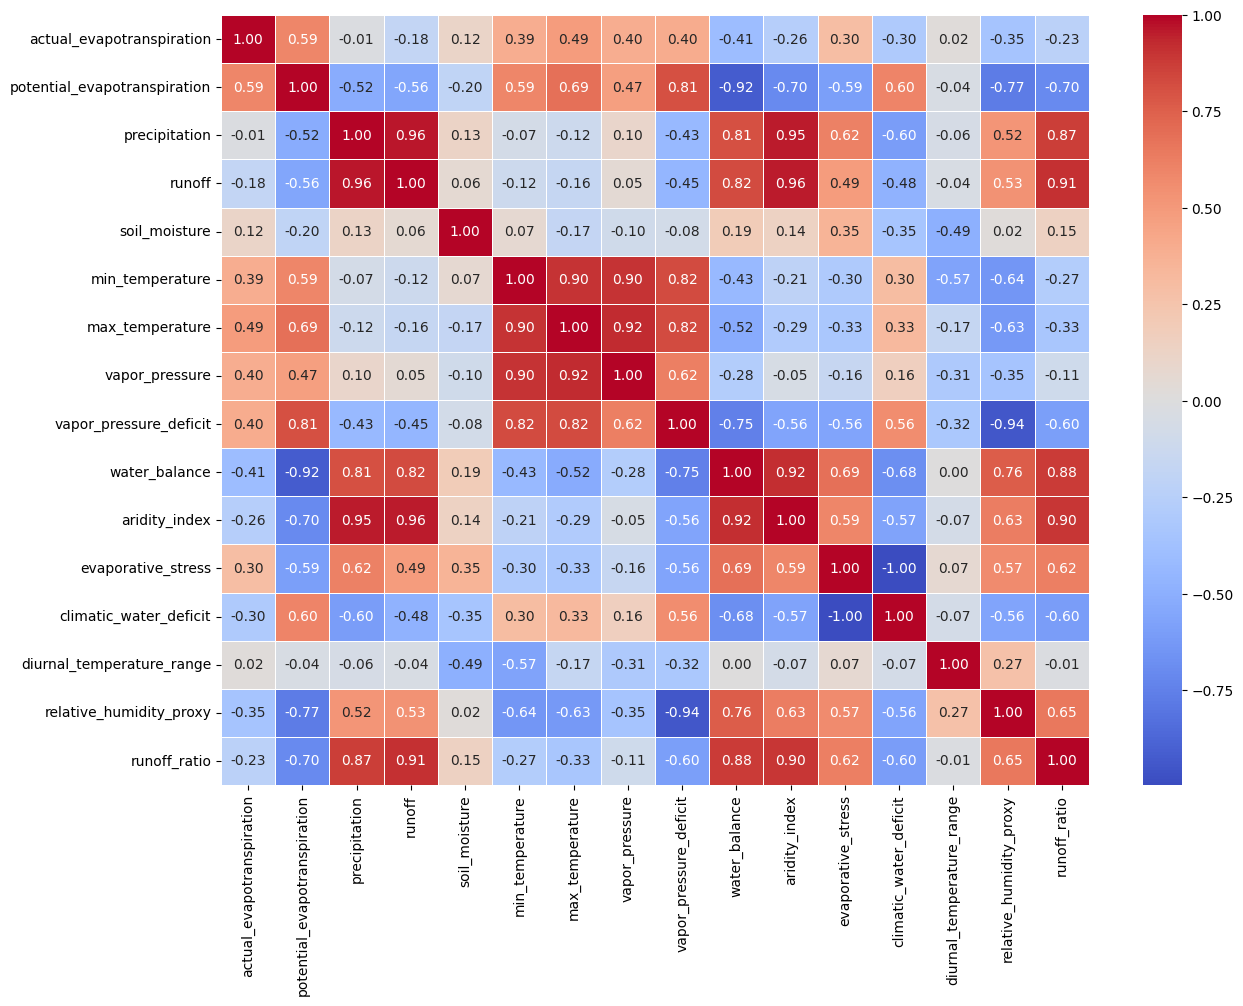

In [14]:
selected_cols = df.drop(columns=['provinsi','kabupaten','monsoon_phase','month','month_cos','month_sin','year'])
data_understanding(selected_cols,'new_label')

## Missing Value Handling

Walaupun presentase missing value dari kecamatan <10%, tetapi karena fokus projek ini adalah klasifikasi per kecamatan, maka imputasi perlu dilakukan dan perlu representatif dalam hasilnya. Untuk mencapai itu, di sini, kami hanya melakukan imputasi untuk kolom ID Kecamatan yang kosong dengan kolom kecamatan dan kabupaten yang masih terisi. (Detail penjelasan dijelaskan di dalam laporan)

In [15]:
both_miss      = ( df['kecamatan_id'].isnull() &  df['kecamatan'].isnull()).sum()
only_id_miss   = ( df['kecamatan_id'].isnull() &  df['kecamatan'].notna()).sum()
only_name_miss = ( df['kecamatan_id'].notna()  &  df['kecamatan'].isnull()).sum()

print(f"Keduanya hilang        : {both_miss} rows")
print(f"Hanya ID hilang (nama ada): {only_id_miss} rows")
print(f"Hanya nama hilang (ID ada): {only_name_miss} rows")

Keduanya hilang        : 192 rows
Hanya ID hilang (nama ada): 24 rows
Hanya nama hilang (ID ada): 0 rows


In [16]:
mask_id_only = df['kecamatan_id'].isnull() & df['kecamatan'].notna()
nama_kandidat = df.loc[mask_id_only, 'kecamatan'].unique()

print(f"Nama kecamatan yang ID-nya hilang: {list(nama_kandidat)}")
print(f"\nDetail per nama:")

for nama in nama_kandidat:
    sub = df[df['kecamatan'] == nama]
    kabupaten_list = sub['kabupaten'].unique()
    n_rows = len(sub)
    print(f"  '{nama}' → {n_rows} rows, ada di kabupaten: {list(kabupaten_list)}")

Nama kecamatan yang ID-nya hilang: ['Wuyuneri']

Detail per nama:
  'Wuyuneri' → 24 rows, ada di kabupaten: ['Puncak Jaya']


In [17]:
print("\nSTEP 4 — Impute Wuyuneri dengan ID '94.02.01.2003 '") # By googling dari hasil identifikasi kode-kode sebelumnya (mencari ID Wuyuneri pada Kab. Puncak Jaya)
print("-" * 60)

mask_wuyuneri = (df['kecamatan'] == 'Wuyuneri') & (df['kecamatan_id'].isnull())
df.loc[mask_wuyuneri, 'kecamatan_id'] = '94.02.01.2003 '

print(f"Rows di-impute: {mask_wuyuneri.sum()}")
print(f"Verifikasi missing kecamatan_id di Wuyuneri: "
      f"{df[df['kecamatan'] == 'Wuyuneri']['kecamatan_id'].isnull().sum()}")


STEP 4 — Impute Wuyuneri dengan ID '94.02.01.2003 '
------------------------------------------------------------
Rows di-impute: 24
Verifikasi missing kecamatan_id di Wuyuneri: 0


In [18]:
df = df.dropna(subset=['kecamatan_id', 'kecamatan']).reset_index(drop=True)
for col in ['kecamatan_id', 'kecamatan', 'kabupaten', 'provinsi']:
    print(df[col].isnull().sum())

0
0
0
0


## Outlier Handling

In [19]:
# Pembagian data
x = df.drop(columns='new_label')
y = df['new_label']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, stratify=y, random_state=42
)

class IQRCapper(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        X = np.array(X)
        Q1 = np.percentile(X, 25, axis=0)
        Q3 = np.percentile(X, 75, axis=0)
        IQR = Q3 - Q1
        self.lower_ = Q1 - 1.5 * IQR
        self.upper_ = Q3 + 1.5 * IQR
        return self

    def transform(self, X, y=None):
        X = np.array(X).copy()
        for i in range(X.shape[1]):
            X[:, i] = np.clip(X[:, i], self.lower_[i], self.upper_[i])
        return X

## Scaling & Encode

In [20]:
target_encoder = LabelEncoder()
y_train_encoded = target_encoder.fit_transform(y_train)
y_test_encoded = target_encoder.transform(y_test)

# Frequency encoding
freq_cols = ['kabupaten', 'kecamatan', 'kecamatan_id']
freq_maps = {}

for col in freq_cols:
    freq_maps[col] = X_train[col].value_counts(normalize=True)
    X_train[col + '_freq'] = X_train[col].map(freq_maps[col])
    X_test[col + '_freq'] = X_test[col].map(freq_maps[col]).fillna(freq_maps[col].min())

# Drop kolom string aslinya
X_train = X_train.drop(columns=freq_cols)
X_test = X_test.drop(columns=freq_cols)

numerical_cols = X_train.select_dtypes(include='number').columns.tolist()

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('capper', IQRCapper()),
        ('scaler', StandardScaler())
    ]), numerical_cols)
])

## SMOTE

In [21]:
# Hitung distribusi kelas dari y_train_encoded
class_counts = Counter(y_train_encoded)
n_majority = max(class_counts.values())

print("Distribusi kelas training:")
for cls, count in sorted(class_counts.items()):
    print(f"  Kelas {cls}: {count} sampel")

# Custom sampling strategy
sampling_strategy = {}
for cls, count in class_counts.items():
    if count == n_majority:
        sampling_strategy[cls] = count                        # mayoritas: tidak disentuh
    elif count == min(class_counts.values()):
        sampling_strategy[cls] = max(count, int(0.4 * n_majority))  # terkecil: boost ke 40%
    else:
        sampling_strategy[cls] = max(count, int(0.6 * n_majority))  # tengah: boost ke 60%

print("\nTarget setelah SMOTE:")
for cls, target in sorted(sampling_strategy.items()):
    orig = class_counts[cls]
    print(f"  Kelas {cls}: {orig} → {target} (+{target - orig})")

Distribusi kelas training:
  Kelas 0: 3385 sampel
  Kelas 1: 1261 sampel

Target setelah SMOTE:
  Kelas 0: 3385 → 3385 (+0)
  Kelas 1: 1261 → 1354 (+93)


# Modeling

In [22]:
candidates = {

    'Random Forest': {
        'classifier': RandomForestClassifier(random_state=42),
        'params': {
            'classifier__n_estimators': [100, 200],
            'classifier__max_depth': [None, 10, 20],
            'classifier__min_samples_split': [2, 5],
            'classifier__class_weight': ['balanced']
        }
    },

    'Decision Tree': {
        'classifier': DecisionTreeClassifier(random_state=42),
        'params': {
            'classifier__max_depth': [None, 5, 10, 20],
            'classifier__min_samples_split': [2, 5, 10],
            'classifier__criterion': ['gini', 'entropy'],
            'classifier__class_weight': ['balanced']
        }
    },

    'SVM': {
        'classifier': SVC(random_state=42),
        'params': {
            'classifier__C': [0.1, 1, 10],
            'classifier__kernel': ['rbf'],
            'classifier__gamma': ['scale', 'auto'],
            'classifier__class_weight': ['balanced']
        }
    }
}

In [23]:
from sklearn.model_selection import RandomizedSearchCV

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
results = {}

for name, config in candidates.items():
    print(f"\n{'='*50}")
    print(f"Training: {name}")
    print('='*50)

    # Buat pipeline baru per model
    pipeline = ImbPipeline([
        ('preprocessor', preprocessor),
        ('smote', SMOTE(
            sampling_strategy=sampling_strategy,
            k_neighbors=1, # Changed from 3 to 1
            random_state=42
        )),
        ('classifier', config['classifier'])
    ])

    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=config['params'],
        cv=cv,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=1
    )

    grid.fit(X_train, y_train_encoded)
    y_pred = grid.best_estimator_.predict(X_test)

    results[name] = {
        'best_params': grid.best_params_,
        'cv_score': round(grid.best_score_, 4),
        'test_acc': round(accuracy_score(y_test_encoded, y_pred), 4),
        'test_f1': round(f1_score(y_test_encoded, y_pred, average='macro'), 4),
        'best_estimator': grid.best_estimator_,
        'y_pred': y_pred
    }

    print(f"Best Params : {grid.best_params_}")
    print(f"CV F1 Macro : {grid.best_score_:.4f}")
    print(f"Test Acc    : {results[name]['test_acc']}")
    print(f"Test F1     : {results[name]['test_f1']}")


Training: Random Forest
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Params : {'classifier__class_weight': 'balanced', 'classifier__max_depth': None, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
CV F1 Macro : 0.9297
Test Acc    : 0.9535
Test F1     : 0.9402

Training: Decision Tree
Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Params : {'classifier__class_weight': 'balanced', 'classifier__criterion': 'entropy', 'classifier__max_depth': 10, 'classifier__min_samples_split': 2}
CV F1 Macro : 0.9047
Test Acc    : 0.9406
Test F1     : 0.9264

Training: SVM
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best Params : {'classifier__C': 10, 'classifier__class_weight': 'balanced', 'classifier__gamma': 'scale', 'classifier__kernel': 'rbf'}
CV F1 Macro : 0.9073
Test Acc    : 0.9398
Test F1     : 0.927


# Evaluation

In [24]:
df_results = pd.DataFrame({
    name: {
        'CV F1 Macro':   v['cv_score'],
        'Test Accuracy': v['test_acc'],
        'Test F1 Macro': v['test_f1']
    }
    for name, v in results.items()
}).T.sort_values('Test F1 Macro', ascending=False)

print("Perbandingan Model")
display(df_results)

Perbandingan Model


,CV F1 Macro,Test Accuracy,Test F1 Macro
Random Forest,0.9297,0.9535,0.9402
SVM,0.9073,0.9398,0.9270
Decision Tree,0.9047,0.9406,0.9264


In [25]:
for name, v in results.items():
    print(f"\n{'='*50}")
    print(f"Classification Report: {name}")
    print('='*50)
    print(classification_report(
        y_test_encoded,
        v['y_pred'],
        target_names=target_encoder.classes_
    ))


Classification Report: Random Forest
              precision    recall  f1-score   support

        mild       0.96      0.98      0.97       847
      severe       0.94      0.89      0.91       315

    accuracy                           0.95      1162
   macro avg       0.95      0.93      0.94      1162
weighted avg       0.95      0.95      0.95      1162


Classification Report: Decision Tree
              precision    recall  f1-score   support

        mild       0.97      0.95      0.96       847
      severe       0.87      0.92      0.89       315

    accuracy                           0.94      1162
   macro avg       0.92      0.94      0.93      1162
weighted avg       0.94      0.94      0.94      1162


Classification Report: SVM
              precision    recall  f1-score   support

        mild       0.99      0.93      0.96       847
      severe       0.84      0.96      0.90       315

    accuracy                           0.94      1162
   macro avg       0.91 

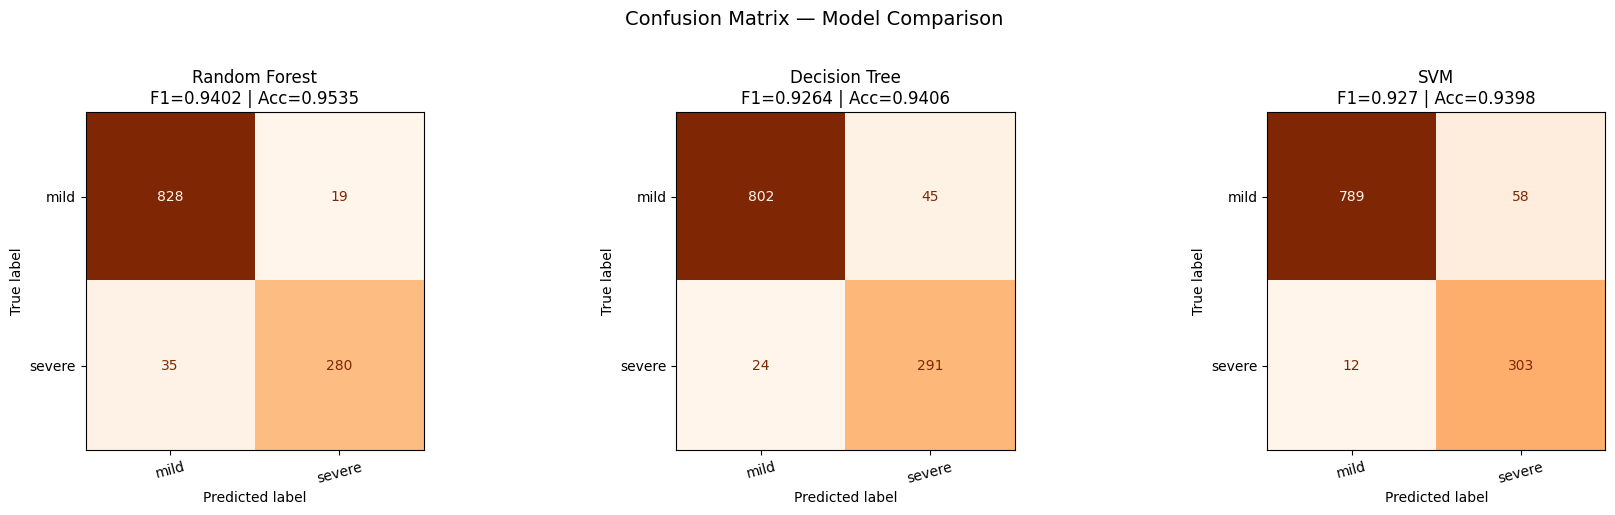

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, v) in zip(axes, results.items()):
    cm = confusion_matrix(y_test_encoded, v['y_pred'])
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=target_encoder.classes_
    )
    disp.plot(cmap='Oranges', ax=ax, colorbar=False)
    ax.set_title(f'{name}\nF1={v["test_f1"]} | Acc={v["test_acc"]}')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Confusion Matrix — Model Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

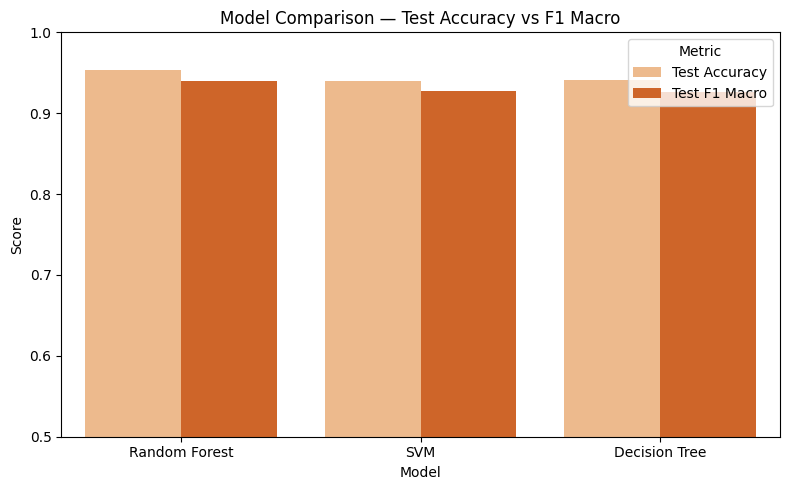

In [27]:
df_plot = df_results[['Test Accuracy', 'Test F1 Macro']].reset_index()
df_plot = df_plot.melt(id_vars='index', var_name='Metric', value_name='Score')

plt.figure(figsize=(8, 5))
sns.barplot(data=df_plot, x='index', y='Score', hue='Metric', palette='Oranges')
plt.title('Model Comparison — Test Accuracy vs F1 Macro')
plt.xlabel('Model')
plt.ylabel('Score')
plt.ylim(0.5, 1.0)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()